# Prepare Projected Population Data for Initial Year and Calibration Year

In [1]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

Go to root directory

In [2]:
if Path.cwd().name == "population_validation":
    os.chdir(Path.cwd().parent)

print(f"Current Directory: {Path.cwd()}")

Current Directory: /work/tuv89272/Calibration_Pipeline_v7_AO


## Import Data From Rasters

In [3]:
districts_raster, _ = read_raster(districts_raster_path)
observed_population_raster, metadata = read_raster(observed_population_raster_path)

nodata = metadata["NODATA_value"]

if observed_population_raster.shape != districts_raster.shape:
    raise ValueError(
        f"Final population raster and district raster have different shapes: {observed_population_raster.shape} vs {districts_raster.shape}"
    )

# Get unique district IDs from full raster, excluding nodata
valid_districts = districts_raster[districts_raster != nodata]
unique_districts = np.unique(valid_districts).astype(int)

print("Unique District IDs:", unique_districts)

# Flatten full rasters
final_observed_population = observed_population_raster.flatten().astype(int)
district = districts_raster.flatten().astype(int)

# Keep only cells valid in all three rasters (initial population, final population, and district)
valid_mask = (
    (final_observed_population != nodata) &
    (district != nodata)
)

final_pop_valid = final_observed_population[valid_mask]
district_valid = district[valid_mask]

# Sum population values per district by using district ID as bin index and population as weight (zonal sum via bincount)
sum_final_population_per_district = np.bincount(district_valid, weights=final_pop_valid)

df = pd.DataFrame({
    f"district_id": unique_districts,
    f"observed_population_{observed_population_year}": [sum_final_population_per_district[d] for d in unique_districts],
})

total_final_population = df[f"observed_population_{observed_population_year}"].sum()
print(f"Total Observed Population in {observed_population_year}: {total_final_population:,.0f}")

df

Unique District IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Total Observed Population in 2020: 33,497,946


,district_id,observed_population_2020
0,1,557574.0
1,2,980219.0
2,3,1303950.0
3,4,383486.0
4,5,325970.0
5,6,1747727.0
6,7,1122187.0
7,8,1532788.0
8,9,2934607.0
9,10,15335762.0


## Total valid pixels

In [4]:
print("Total valid pixels:", valid_mask.sum())

Total valid pixels: 50745


## Generate Backwards Projected Population Raster for Initial Year

In [7]:
SCALE_FACTOR = TARGET_POPULATION_INITIAL_YEAR / df[f"observed_population_{observed_population_year}"].sum()

# Start from full raster
initial_population_projected_raster = observed_population_raster.astype(float).copy()

# Scale only valid cells
valid_mask = (
    (observed_population_raster != nodata) &
    (districts_raster != nodata)
)

initial_population_projected_raster[valid_mask] = np.round(observed_population_raster[valid_mask] * SCALE_FACTOR)

# Keep nodata cells unchanged
initial_population_projected_raster[~valid_mask] = nodata

initial_population_projected_raster_path_unscaled = f"{generated_data_path}/{country_code}_population_backwards_projected_{initial_year}_unscaled.asc"

write_raster(
    raster=initial_population_projected_raster,
    file=initial_population_projected_raster_path_unscaled,
    xllcorner=metadata["xllcorner"],
    yllcorner=metadata["yllcorner"],
    cellsize=metadata["cellsize"],
    mask_raster=districts_raster,  # preserve nodata areas
    nodata=nodata,
    fmt="%d",
)

In [8]:
initial_population_projected_raster_to_verify, _ = read_raster(initial_population_projected_raster_path_unscaled)

# Verify that the sum of the scaled population matches the target
target_population_projected_valid = initial_population_projected_raster_to_verify[valid_mask]
sum_target_population_projected_per_district = np.bincount(district_valid, weights=target_population_projected_valid)

print(f"Scale factor: {SCALE_FACTOR:.6f}")
print(f"Projected population in {calibration_year}: {target_population_projected_valid.sum():,.1f} (target: {TARGET_POPULATION_CALIBRATION_YEAR:,.1f})")

Scale factor: 0.754647
Projected population in 2024: 25,279,670.0 (target: 37,885,849.0)


## Generate Projected Population Raster for Calibration Year Using Observed Population Raster

In [9]:
SCALE_FACTOR = TARGET_POPULATION_CALIBRATION_YEAR / df[f"observed_population_{observed_population_year}"].sum()

# Start from full raster
target_year_population_projected_raster = observed_population_raster.astype(float).copy()

# Scale only valid cells
valid_mask = (
    (observed_population_raster != nodata) &
    (districts_raster != nodata)
)

target_year_population_projected_raster[valid_mask] = np.round(observed_population_raster[valid_mask] * SCALE_FACTOR)

# Keep nodata cells unchanged
target_year_population_projected_raster[~valid_mask] = nodata

write_raster(
    raster=target_year_population_projected_raster,
    file=projected_population_calibration_year_raster_path,
    xllcorner=metadata["xllcorner"],
    yllcorner=metadata["yllcorner"],
    cellsize=metadata["cellsize"],
    mask_raster=districts_raster,  # preserve nodata areas
    nodata=nodata,
    fmt="%d",
)

In [10]:
target_population_projected_raster, _ = read_raster(projected_population_calibration_year_raster_path)

# Verify that the sum of the scaled population matches the target
target_population_projected_valid = target_population_projected_raster[valid_mask]
sum_target_population_projected_per_district = np.bincount(district_valid, weights=target_population_projected_valid)

print(f"Scale factor: {SCALE_FACTOR}")
print(f"Projected population in {calibration_year}: {target_population_projected_valid.sum():,.1f} (target: {TARGET_POPULATION_CALIBRATION_YEAR:,.1f})")

Scale factor: 1.130990210563955
Projected population in 2024: 37,886,211.0 (target: 37,885,849.0)


## Plot Observed vs Projected Population Map Difference

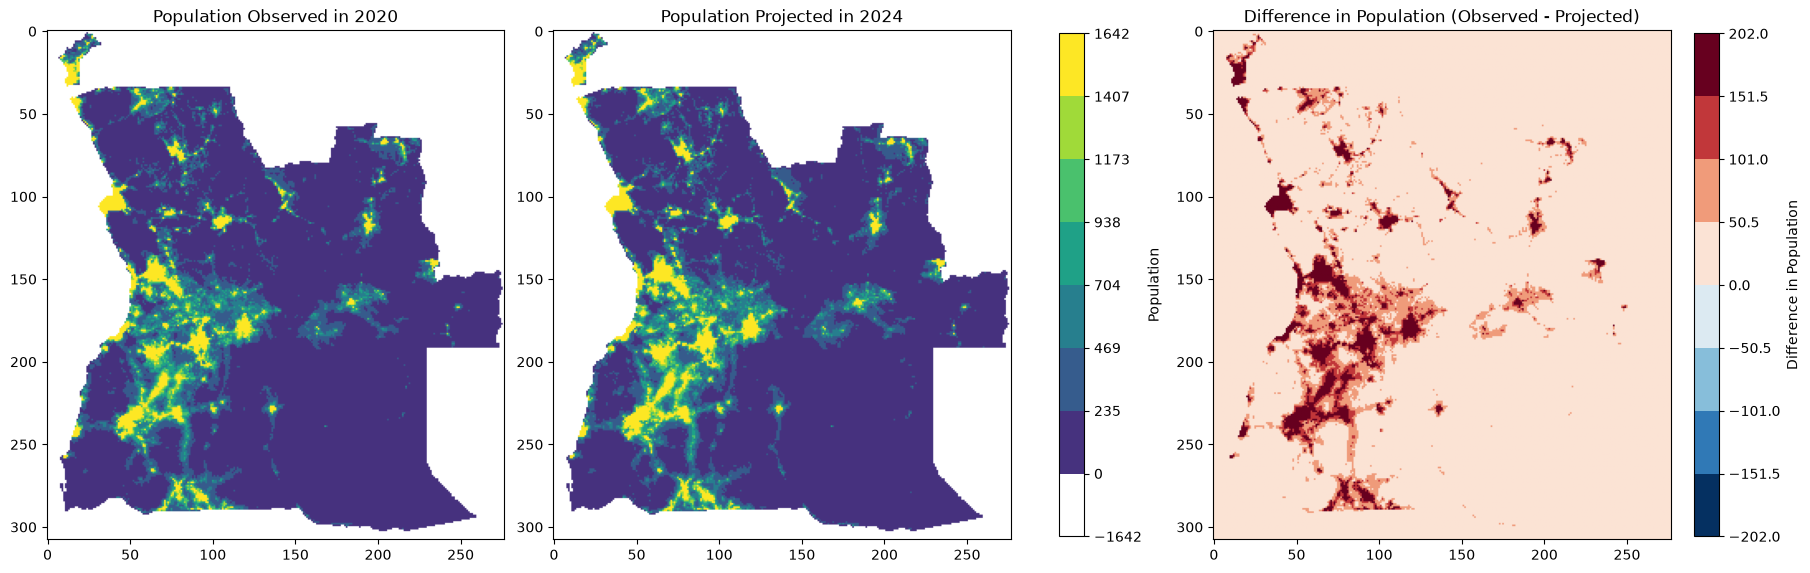

In [11]:
observed_population, _ = read_raster(observed_population_raster_path)
projected_population, _ = read_raster(projected_population_calibration_year_raster_path)

# Difference map (Projected - Observed)
population_difference = projected_population - observed_population

# Where sim is nodata but obs exists → sim "contributed 0", so diff = -obs
missing_sim_mask = ~np.isfinite(projected_population) & np.isfinite(observed_population)
population_difference[missing_sim_mask] = -observed_population[missing_sim_mask]

# Where obs is nodata (can't compare) → keep as NaN
population_difference[~np.isfinite(observed_population)] = np.nan

# -----------------------
# Robust linear limits (prevents outliers from crushing contrast)
# -----------------------
combined = np.r_[observed_population[np.isfinite(observed_population)].ravel(), projected_population[np.isfinite(projected_population)].ravel()]

# tweak these if needed
lo, hi = 2, 98
vmin = np.nanpercentile(combined, lo)
vmax = np.nanpercentile(combined, hi)

# -----------------------
# 8-band colormap for Population (Obs/Sim)
# -----------------------
n_bins = 8
bounds = np.r_[-vmax, 0, np.linspace(0, vmax, n_bins)[1:]]

base = plt.get_cmap("viridis", n_bins)        # discretize viridis into 8 colors
bg_white_color = np.array([[1,1,1,1]])
cmap_pop = ListedColormap(np.vstack([bg_white_color, plt.get_cmap("viridis", n_bins)(np.arange(1, n_bins))]))
norm_pop = BoundaryNorm(bounds, cmap_pop.N, clip=True)

# -----------------------
# 8-band diverging for Difference (symmetric, robust)
# -----------------------
dmax = np.nanpercentile(np.abs(population_difference[np.isfinite(population_difference)]), 98)
dbounds = np.linspace(-dmax, dmax, n_bins + 1)

base_d = plt.get_cmap("RdBu_r", n_bins)
cmap_diff = ListedColormap(base_d(np.arange(n_bins)))
norm_diff = BoundaryNorm(dbounds, cmap_diff.N, clip=True)

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(observed_population, cmap=cmap_pop, norm=norm_pop, zorder=2)
axes[0].set_title(f"Population Observed in {observed_population_year}")

im1 = axes[1].imshow(projected_population, cmap=cmap_pop, norm=norm_pop, zorder=2)
axes[1].set_title(f"Population Projected in {calibration_year}")

im2 = axes[2].imshow(population_difference, cmap=cmap_diff, norm=norm_diff, zorder=2)
axes[2].set_title(f"Difference in Population (Observed - Projected)")

# Colorbars (banded)
cbar1 = fig.colorbar(im1, ax=axes[:2], shrink=0.85, boundaries=bounds)
cbar1.set_label("Population")
cbar1.set_ticks(bounds)  # show band edges (or use bounds[::2] for fewer ticks)

cbar2 = fig.colorbar(im2, ax=axes[2], shrink=0.85, boundaries=dbounds)
cbar2.set_label("Difference in Population")
cbar2.set_ticks(dbounds)

plt.savefig(f"{data_path}/observed_{observed_population_year}_vs_projected_{calibration_year}_population_pixel_maps.png", dpi=200)
plt.show()

### Write to csv

In [12]:
df[f'population_{calibration_year}_projected'] = df[f"observed_population_{observed_population_year}"] * SCALE_FACTOR

observed_population_sum = df[f"observed_population_{observed_population_year}"].sum()
projected_population_sum = df[f"population_{calibration_year}_projected"].sum()


# print(f'Initial population sum: {init_pop_sum:,.2f}')
print(f'Final population observed sum ({observed_population_year}): {observed_population_sum:,.2f}')
print(f'Final population projected sum ({calibration_year}): {projected_population_sum:,.2f}')

df.to_csv(population_per_district_projected_csv_path, index=False)

print(f"Wrote projected population per district to {population_per_district_projected_csv_path}")

Final population observed sum (2020): 33,497,946.00
Final population projected sum (2024): 37,885,849.00
Wrote projected population per district to generated/population_per_district_projected_2024.csv


# Prepare Incidence Data for Calibration Year to Compare to Results of Simulation

## Scale incidence from population

In [13]:
pop_df = pd.read_csv(population_per_district_projected_csv_path)
pop_df

,district_id,observed_population_2020,population_2024_projected
0,1,557574.0,6.306107e+05
1,2,980219.0,1.108618e+06
2,3,1303950.0,1.474755e+06
3,4,383486.0,4.337189e+05
4,5,325970.0,3.686689e+05
5,6,1747727.0,1.976662e+06
6,7,1122187.0,1.269183e+06
7,8,1532788.0,1.733568e+06
8,9,2934607.0,3.319012e+06
9,10,15335762.0,1.734460e+07


In [14]:
# incidence_per_1000 = pd.read_csv(incidence_data_csv_path)
# incidence_per_1000 = incidence_per_1000.dropna()
# incidence_per_1000

In [15]:
# data_df = pop_df.merge(incidence_per_1000, left_on="district_id", right_on="Region ID", how="left")
# data_df

In [16]:
# data_df.to_csv(f"{population_incidence_per_district_csv_path}", index=False)

# print(f"Wrote population and incidence per district to {population_incidence_per_district_csv_path}")

### Birthrate from initial to calibration year based on initial population and final observed population

In [17]:
# period = calibration_year - initial_year
# population_diff = data_df[f'final_population_{calibration_year}_projected'] - data_df['init_population']
# change_each_year = population_diff / period

# # Build a neat summary table
# result_df = data_df[["district_id", "init_population", f'final_population_{calibration_year}_projected']].copy()
# result_df["population_diff"] = population_diff
# result_df["change_per_year"] = change_each_year

# # Formatters for nice printing
# formatters = {
#     "district_id": lambda x: f"{int(x)}",
#     "init_population": lambda x: f"{x:,.0f}",
#     f'final_population_{calibration_year}_projected': lambda x: f"{x:,.0f}",
#     "population_diff": lambda x: f"{x:,.0f}",
#     "change_per_year": lambda x: f"{x:,.2f}",
# }

# print(f"Population change per district over {period} years (average per year):\n")
# print(result_df.to_string(index=False, formatters=formatters))